Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 166ms/step - accuracy: 0.7904 - loss: 0.4377 - val_accuracy: 0.8480 - val_loss: 0.3798
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8355 - loss: 0.4081

Loss: 0.40810027718544006
Accuracy: 0.8355200290679932
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step

Sample Predictions:

Review 1 : Negative
Review 2 : Positive
Review 3 : Negative
Review 4 : Negative
Review 5 : Positive


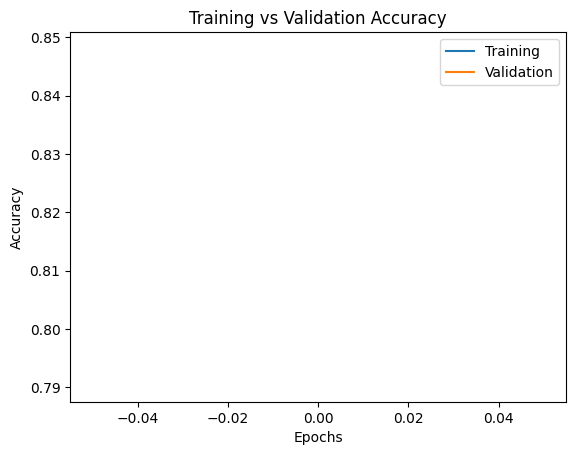

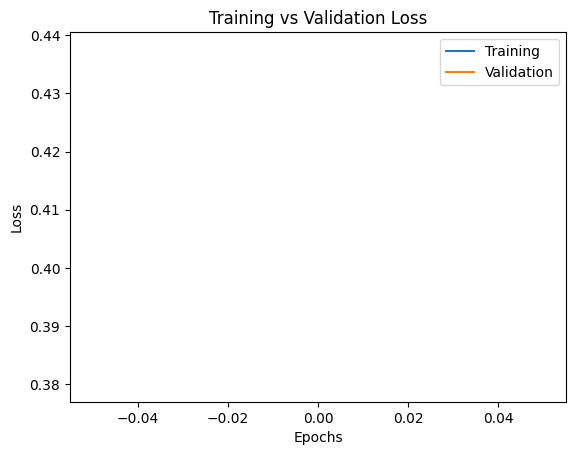

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Make all reviews same length
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

# Build Deep Neural Network
model = tf.keras.models.Sequential([

    # Word Embedding Layer
    tf.keras.layers.Embedding(
        input_dim=10000,
        output_dim=64
    ),

    # LSTM Layer
    tf.keras.layers.LSTM(64),

    # Hidden Layer
    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    # Output Layer
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show Model Summary
model.summary()

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=64,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nLoss: {loss}")
print(f"Accuracy: {accuracy}")

# Predict Sentiment
predictions = model.predict(X_test)

print("\nSample Predictions:\n")

for i in range(5):

    if predictions[i][0] > 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print(
        "Review",
        i + 1,
        ":",
        sentiment
    )

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()